In [3]:
# !pip install xgboost

In [22]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt

In [5]:
pred_result = pd.read_csv('data/result_all_df.csv')
pred_result

,sales_id,expected_dt,ae_all_1
0,3630,2025-01-09,0
1,5986,2024-09-11,0
2,7036,2025-05-28,0
3,628,2025-01-09,0
4,6352,2024-11-30,0
...,...,...,...
9995,3178,2025-04-29,0
9996,9980,2025-02-08,0
9997,1440,2025-02-17,1
9998,8684,2024-12-05,0


In [6]:
X_scaled_train_all = pd.read_csv('data/X_scaled_train_all.csv')
X_scaled_train_all

,rule_10_l12,rule_10_l24,rule_10_l3,rule_10_l36,rule_10_l6,rule_10_l9,rule_1_l12,rule_1_l24,rule_1_l3,rule_1_l36,...,rule_8_l3,rule_8_l36,rule_8_l6,rule_8_l9,rule_9_l12,rule_9_l24,rule_9_l3,rule_9_l36,rule_9_l6,rule_9_l9
0,0.781991,-0.560466,-0.113512,1.018084,-0.268235,1.474837,1.295927,-1.319330,-0.356585,0.949133,...,-0.929623,-0.693300,0.564041,0.529473,-0.764982,-0.783341,0.063529,-0.748693,-1.105220,-0.293641
1,0.370138,-1.124187,-1.807820,-2.161642,1.296443,-0.673684,1.896395,2.155237,0.690995,1.380100,...,-0.303797,-0.083304,0.303517,0.181481,0.386287,-0.905138,-1.346002,-0.024458,-1.083728,0.272316
2,-0.375557,-0.253502,1.666952,-0.749296,0.368630,0.579478,-0.416250,-0.140122,0.866615,1.261036,...,-0.407437,-0.311739,-1.235039,-0.504359,-1.083966,-0.171115,-1.583421,0.127974,0.965250,0.310824
3,1.279729,0.615224,-1.080205,-0.036350,-0.688423,1.151902,-0.913733,-1.213227,0.722840,-0.780575,...,-0.083097,-0.808971,-0.425652,0.340335,1.308676,-0.085084,-2.696878,-0.935811,0.886620,1.889077
4,0.382294,0.956135,-1.091419,-0.231600,-1.198234,-0.198231,-0.047181,-0.187740,-1.424141,1.251307,...,0.039025,-1.646433,0.060067,-0.512130,0.825402,0.125811,-0.718492,-1.281370,-0.606970,-1.320889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,0.606150,0.567432,-1.530641,1.497238,1.238925,0.123612,0.002293,-0.120525,-0.084149,-0.366128,...,1.305701,0.268819,0.239711,1.613915,-1.014952,-0.079813,0.861765,0.985831,-0.127932,-1.050578
7996,0.139365,-0.591334,0.468173,0.116863,1.244895,0.156344,0.254636,-0.661731,-0.286355,-0.345954,...,0.304844,0.077136,-0.887023,-0.047139,1.686907,1.520747,-1.816422,-0.846067,-0.700519,0.371308
7997,-1.013252,-2.185082,-1.218263,1.163953,2.578457,-1.108387,0.512003,-2.122257,0.614396,-0.417708,...,-1.030290,-1.783504,-1.349433,1.578453,1.267571,0.017412,0.330099,-0.350033,0.693707,1.151154
7998,-0.705346,-0.290348,-0.327486,-2.138359,-0.769434,-0.082611,0.736493,0.145769,1.435556,0.905095,...,-1.411850,-1.854692,0.332944,-0.723054,1.387146,0.198844,0.010363,-0.005722,-0.675763,-0.128814


In [7]:
X_scaled_test = pd.read_csv('data/X_scaled_test.csv')
X_scaled_test

,rule_10_l12,rule_10_l24,rule_10_l3,rule_10_l36,rule_10_l6,rule_10_l9,rule_1_l12,rule_1_l24,rule_1_l3,rule_1_l36,...,rule_8_l3,rule_8_l36,rule_8_l6,rule_8_l9,rule_9_l12,rule_9_l24,rule_9_l3,rule_9_l36,rule_9_l6,rule_9_l9
0,0.790882,1.916791,-0.674982,0.441718,-1.312054,-0.131609,1.012686,-0.800499,1.910166,-0.260050,...,-0.308201,-0.785200,0.395801,0.378735,-0.824878,1.270780,0.871449,-1.753587,-0.516695,-0.815759
1,-0.537469,0.738986,1.195537,-0.017837,1.388942,-0.824715,0.210573,0.990788,-0.297437,-0.290168,...,-0.704338,-1.621611,-0.481805,-0.342290,1.427779,0.929524,-0.367740,0.220300,1.188465,-0.617010
2,-2.128272,1.471513,0.962662,-2.619804,-0.318998,-0.258547,1.563183,-0.418170,0.746014,-0.019506,...,-0.856798,1.543320,-0.085117,-0.750943,-0.885397,0.178245,0.359770,0.615685,-0.303512,-1.036506
3,-0.065761,-0.999540,-0.307952,0.918337,-0.078899,-0.917440,1.145616,-0.446522,0.499703,0.654366,...,0.812766,0.413579,0.938487,-0.841306,-1.225136,-0.546440,-0.413603,-0.632243,1.361616,0.603613
4,0.744542,0.635573,1.191754,-1.432109,-1.422568,0.429254,0.896621,0.323020,0.188501,1.305857,...,-0.092288,-0.014063,0.795025,-0.850856,1.343010,0.345031,0.517268,0.707665,0.577415,1.255870
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,-1.107875,0.203994,-0.167513,-1.699835,0.867546,0.114220,0.113801,-0.326790,-1.313297,-1.144345,...,-0.603975,-0.702389,-1.262779,-0.413300,-0.624113,-0.993919,-0.343315,0.915183,-0.274927,1.908609
1996,-0.201541,-0.594700,-1.565921,0.171112,0.973037,-0.664781,2.418158,-1.254400,-2.085877,0.492309,...,0.294817,0.350903,1.064400,0.933703,0.798060,0.190333,0.616996,0.000611,0.870364,0.974500
1997,3.343489,0.455270,6.940221,3.911248,2.075707,-0.504551,5.547428,2.952826,3.184443,3.478191,...,3.294635,4.467441,4.893203,1.224146,1.671015,5.482328,-1.418781,4.100537,3.766376,0.481948
1998,-2.205482,-0.641170,-0.459930,0.011765,0.381464,0.975742,0.080967,0.605269,0.744854,1.559177,...,0.507830,-0.909324,0.353214,-0.707524,0.766898,-0.489350,1.462390,0.435340,-1.446078,0.751384


# Modeling

In [16]:
X = pd.concat([X_scaled_train_all,X_scaled_test],axis=0).reset_index(drop=True)
X

,rule_10_l12,rule_10_l24,rule_10_l3,rule_10_l36,rule_10_l6,rule_10_l9,rule_1_l12,rule_1_l24,rule_1_l3,rule_1_l36,...,rule_8_l3,rule_8_l36,rule_8_l6,rule_8_l9,rule_9_l12,rule_9_l24,rule_9_l3,rule_9_l36,rule_9_l6,rule_9_l9
0,0.781991,-0.560466,-0.113512,1.018084,-0.268235,1.474837,1.295927,-1.319330,-0.356585,0.949133,...,-0.929623,-0.693300,0.564041,0.529473,-0.764982,-0.783341,0.063529,-0.748693,-1.105220,-0.293641
1,0.370138,-1.124187,-1.807820,-2.161642,1.296443,-0.673684,1.896395,2.155237,0.690995,1.380100,...,-0.303797,-0.083304,0.303517,0.181481,0.386287,-0.905138,-1.346002,-0.024458,-1.083728,0.272316
2,-0.375557,-0.253502,1.666952,-0.749296,0.368630,0.579478,-0.416250,-0.140122,0.866615,1.261036,...,-0.407437,-0.311739,-1.235039,-0.504359,-1.083966,-0.171115,-1.583421,0.127974,0.965250,0.310824
3,1.279729,0.615224,-1.080205,-0.036350,-0.688423,1.151902,-0.913733,-1.213227,0.722840,-0.780575,...,-0.083097,-0.808971,-0.425652,0.340335,1.308676,-0.085084,-2.696878,-0.935811,0.886620,1.889077
4,0.382294,0.956135,-1.091419,-0.231600,-1.198234,-0.198231,-0.047181,-0.187740,-1.424141,1.251307,...,0.039025,-1.646433,0.060067,-0.512130,0.825402,0.125811,-0.718492,-1.281370,-0.606970,-1.320889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,-1.107875,0.203994,-0.167513,-1.699835,0.867546,0.114220,0.113801,-0.326790,-1.313297,-1.144345,...,-0.603975,-0.702389,-1.262779,-0.413300,-0.624113,-0.993919,-0.343315,0.915183,-0.274927,1.908609
9996,-0.201541,-0.594700,-1.565921,0.171112,0.973037,-0.664781,2.418158,-1.254400,-2.085877,0.492309,...,0.294817,0.350903,1.064400,0.933703,0.798060,0.190333,0.616996,0.000611,0.870364,0.974500
9997,3.343489,0.455270,6.940221,3.911248,2.075707,-0.504551,5.547428,2.952826,3.184443,3.478191,...,3.294635,4.467441,4.893203,1.224146,1.671015,5.482328,-1.418781,4.100537,3.766376,0.481948
9998,-2.205482,-0.641170,-0.459930,0.011765,0.381464,0.975742,0.080967,0.605269,0.744854,1.559177,...,0.507830,-0.909324,0.353214,-0.707524,0.766898,-0.489350,1.462390,0.435340,-1.446078,0.751384


In [9]:
Y = pred_result['ae_all_1']
Y

0       0
1       0
2       0
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    0
9999    0
Name: ae_all_1, Length: 10000, dtype: int64

In [15]:
pred_result

,sales_id,expected_dt,ae_all_1
0,3630,2025-01-09,0
1,5986,2024-09-11,0
2,7036,2025-05-28,0
3,628,2025-01-09,0
4,6352,2024-11-30,0
...,...,...,...
9995,3178,2025-04-29,0
9996,9980,2025-02-08,0
9997,1440,2025-02-17,1
9998,8684,2024-12-05,0


In [18]:
df_xy = pd.concat([X,pred_result],axis=1)
df_xy = df_xy.rename(columns={'ae_all_1':'y_pred'})
df_xy

,rule_10_l12,rule_10_l24,rule_10_l3,rule_10_l36,rule_10_l6,rule_10_l9,rule_1_l12,rule_1_l24,rule_1_l3,rule_1_l36,...,rule_8_l9,rule_9_l12,rule_9_l24,rule_9_l3,rule_9_l36,rule_9_l6,rule_9_l9,sales_id,expected_dt,y_pred
0,0.781991,-0.560466,-0.113512,1.018084,-0.268235,1.474837,1.295927,-1.319330,-0.356585,0.949133,...,0.529473,-0.764982,-0.783341,0.063529,-0.748693,-1.105220,-0.293641,3630,2025-01-09,0
1,0.370138,-1.124187,-1.807820,-2.161642,1.296443,-0.673684,1.896395,2.155237,0.690995,1.380100,...,0.181481,0.386287,-0.905138,-1.346002,-0.024458,-1.083728,0.272316,5986,2024-09-11,0
2,-0.375557,-0.253502,1.666952,-0.749296,0.368630,0.579478,-0.416250,-0.140122,0.866615,1.261036,...,-0.504359,-1.083966,-0.171115,-1.583421,0.127974,0.965250,0.310824,7036,2025-05-28,0
3,1.279729,0.615224,-1.080205,-0.036350,-0.688423,1.151902,-0.913733,-1.213227,0.722840,-0.780575,...,0.340335,1.308676,-0.085084,-2.696878,-0.935811,0.886620,1.889077,628,2025-01-09,0
4,0.382294,0.956135,-1.091419,-0.231600,-1.198234,-0.198231,-0.047181,-0.187740,-1.424141,1.251307,...,-0.512130,0.825402,0.125811,-0.718492,-1.281370,-0.606970,-1.320889,6352,2024-11-30,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,-1.107875,0.203994,-0.167513,-1.699835,0.867546,0.114220,0.113801,-0.326790,-1.313297,-1.144345,...,-0.413300,-0.624113,-0.993919,-0.343315,0.915183,-0.274927,1.908609,3178,2025-04-29,0
9996,-0.201541,-0.594700,-1.565921,0.171112,0.973037,-0.664781,2.418158,-1.254400,-2.085877,0.492309,...,0.933703,0.798060,0.190333,0.616996,0.000611,0.870364,0.974500,9980,2025-02-08,0
9997,3.343489,0.455270,6.940221,3.911248,2.075707,-0.504551,5.547428,2.952826,3.184443,3.478191,...,1.224146,1.671015,5.482328,-1.418781,4.100537,3.766376,0.481948,1440,2025-02-17,1
9998,-2.205482,-0.641170,-0.459930,0.011765,0.381464,0.975742,0.080967,0.605269,0.744854,1.559177,...,-0.707524,0.766898,-0.489350,1.462390,0.435340,-1.446078,0.751384,8684,2024-12-05,0


In [12]:
model = xgb.XGBClassifier()
model.fit(X, Y)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [13]:
Y_prob = model.predict_proba(X)[:, 1]

In [19]:
df_final = df_xy.copy()
df_final['y_proba'] = Y_prob

In [20]:
df_final

,rule_10_l12,rule_10_l24,rule_10_l3,rule_10_l36,rule_10_l6,rule_10_l9,rule_1_l12,rule_1_l24,rule_1_l3,rule_1_l36,...,rule_9_l12,rule_9_l24,rule_9_l3,rule_9_l36,rule_9_l6,rule_9_l9,sales_id,expected_dt,y_pred,y_proba
0,0.781991,-0.560466,-0.113512,1.018084,-0.268235,1.474837,1.295927,-1.319330,-0.356585,0.949133,...,-0.764982,-0.783341,0.063529,-0.748693,-1.105220,-0.293641,3630,2025-01-09,0,0.000503
1,0.370138,-1.124187,-1.807820,-2.161642,1.296443,-0.673684,1.896395,2.155237,0.690995,1.380100,...,0.386287,-0.905138,-1.346002,-0.024458,-1.083728,0.272316,5986,2024-09-11,0,0.007235
2,-0.375557,-0.253502,1.666952,-0.749296,0.368630,0.579478,-0.416250,-0.140122,0.866615,1.261036,...,-1.083966,-0.171115,-1.583421,0.127974,0.965250,0.310824,7036,2025-05-28,0,0.000018
3,1.279729,0.615224,-1.080205,-0.036350,-0.688423,1.151902,-0.913733,-1.213227,0.722840,-0.780575,...,1.308676,-0.085084,-2.696878,-0.935811,0.886620,1.889077,628,2025-01-09,0,0.003532
4,0.382294,0.956135,-1.091419,-0.231600,-1.198234,-0.198231,-0.047181,-0.187740,-1.424141,1.251307,...,0.825402,0.125811,-0.718492,-1.281370,-0.606970,-1.320889,6352,2024-11-30,0,0.000431
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,-1.107875,0.203994,-0.167513,-1.699835,0.867546,0.114220,0.113801,-0.326790,-1.313297,-1.144345,...,-0.624113,-0.993919,-0.343315,0.915183,-0.274927,1.908609,3178,2025-04-29,0,0.003392
9996,-0.201541,-0.594700,-1.565921,0.171112,0.973037,-0.664781,2.418158,-1.254400,-2.085877,0.492309,...,0.798060,0.190333,0.616996,0.000611,0.870364,0.974500,9980,2025-02-08,0,0.000096
9997,3.343489,0.455270,6.940221,3.911248,2.075707,-0.504551,5.547428,2.952826,3.184443,3.478191,...,1.671015,5.482328,-1.418781,4.100537,3.766376,0.481948,1440,2025-02-17,1,0.999994
9998,-2.205482,-0.641170,-0.459930,0.011765,0.381464,0.975742,0.080967,0.605269,0.744854,1.559177,...,0.766898,-0.489350,1.462390,0.435340,-1.446078,0.751384,8684,2024-12-05,0,0.000569


In [24]:
df_final[df_final['y_pred']==1]

,rule_10_l12,rule_10_l24,rule_10_l3,rule_10_l36,rule_10_l6,rule_10_l9,rule_1_l12,rule_1_l24,rule_1_l3,rule_1_l36,...,rule_9_l12,rule_9_l24,rule_9_l3,rule_9_l36,rule_9_l6,rule_9_l9,sales_id,expected_dt,y_pred,y_proba
5,-1.880556,-0.629963,-0.763022,1.258766,0.062159,2.426459,1.446597,-0.446344,0.944030,-1.572808,...,-0.479399,-0.573583,2.105880,-0.231126,-2.439374,0.493644,8271,2025-04-13,1,0.963781
19,3.663749,3.697037,2.215331,-0.279427,1.518622,1.151167,4.685324,2.403807,2.952034,3.706659,...,3.719768,5.279992,0.689017,3.815989,5.191506,0.346684,7598,2025-01-07,1,0.999990
28,2.230227,-1.050311,3.781501,3.005494,3.252226,4.017178,3.304338,3.407197,3.268929,3.656235,...,-1.859777,0.059449,7.102892,5.492760,6.264691,3.596265,9814,2025-04-23,1,0.999845
32,1.225023,0.027889,-2.024022,0.186240,-0.941447,1.127069,0.431087,-1.109613,0.137462,-1.017464,...,-2.557889,0.808390,0.232959,0.518583,-0.338970,-1.850666,1831,2025-05-17,1,0.985790
43,0.920677,3.171207,1.483924,3.582473,-1.450000,5.415632,3.711875,4.533238,0.523453,2.091130,...,2.207659,3.215019,1.463205,3.620806,-0.509612,4.427415,5422,2025-02-06,1,0.999874
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9890,6.163798,4.995207,2.325418,4.933733,4.919793,4.903311,5.756888,0.497278,0.623872,2.919889,...,2.674088,2.548809,5.299000,3.811896,4.126485,2.445384,9129,2025-02-21,1,0.999973
9904,-0.330177,-1.633810,0.100105,1.424071,1.389454,0.480058,1.392068,-1.369691,-0.708094,0.119879,...,-0.175160,1.554952,-0.936011,0.197878,0.368962,-0.800775,4595,2024-10-30,1,0.967510
9930,1.792609,3.093392,0.784284,-1.744206,3.219466,2.146679,1.634871,0.449766,3.823150,3.557666,...,0.238116,3.280079,4.149774,4.478531,3.975993,4.751277,8160,2025-05-07,1,0.999996
9937,1.892297,6.365798,1.958301,2.058423,2.333277,4.373809,1.064543,1.561675,4.268232,-0.347471,...,1.738128,6.511052,3.819984,2.654050,2.398088,1.405546,3506,2024-10-05,1,0.999988


# Analysis

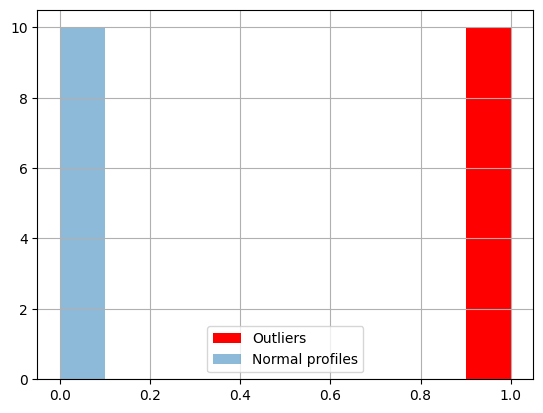

In [23]:
bin_width = 0.1
plt.hist(df_final[df_final['y_pred'] == 1]['y_proba'], label = 'Outliers', 
         density = True, 
         color = 'red',
         bins = np.arange(0, 1+bin_width, bin_width)
        )

plt.hist(df_final[df_final['y_pred'] == 0]['y_proba'], label = 'Normal profiles', 
         density = True, 
         bins = np.arange(0, 1+bin_width, bin_width),
        alpha = 0.5)
plt.legend()
plt.grid()
plt.show()

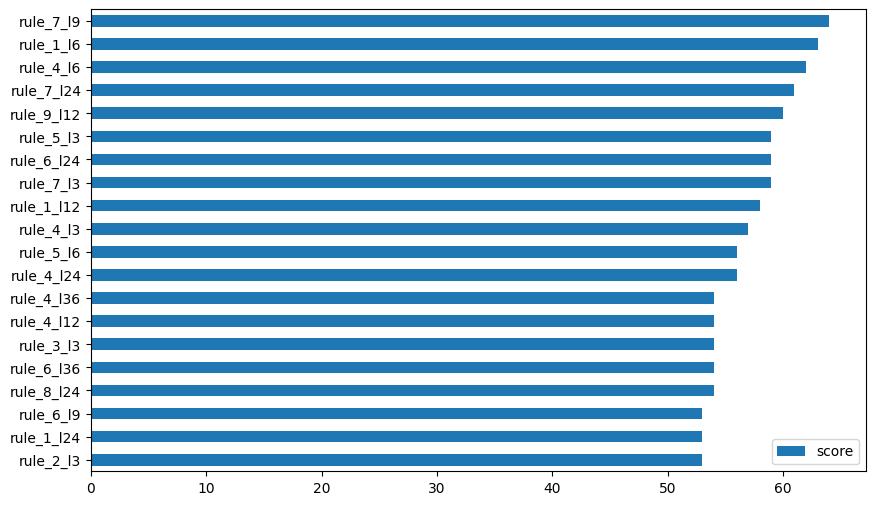

In [25]:
feature_importance = model.get_booster().get_score(importance_type='weight')
keys = list(feature_importance.keys())
values = list(feature_importance.values())

data_importance  = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=True)
data_importance.tail(20).plot(kind='barh', figsize = (10,6))
plt.show()